2025-12-05 20:54:42.711 | INFO     | product_tagger.config:<module>:12 - PROJ_ROOT path is: C:\importante\Master\VC3\TP-VPC3
c:\importante\Master\VC3\TP-VPC3\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025-12-05 20:54:45.140 | INFO     | product_tagger.config:<module>:64 - [MLflow] tracking_uri = file:///C:/importante/Master/VC3/TP-VPC3/mlruns
2025-12-05 20:54:45.144 | INFO     | product_tagger.config:<module>:67 - [MLflow] experiment 'vit_aug_loss' -> id=899493669112892091, artifact_location=file:///C:/importante/Master/VC3/TP-VPC3/mlruns/899493669112892091


IMG_DIR = C:/importante/Master/VC3/TP-VPC3/data/processed/images/test
Device: cuda
Using model file: C:\importante\Master\VC3\TP-VPC3\models\vit_articleType_aug.pt
2025-12-05 20:54:47.727 | INFO     | product_tagger.modeling.vit:create_vit_model:64 - Created ViT-B/16 model with 124 output classes.
Model loaded with 124 classes.
Testing these images:
 - 1163.jpg
 - 1530.jpg
 - 1535.jpg
 - 1543.jpg
 - 1546.jpg

🖼 Image: 1163.jpg
   Predicted: Tshirts
   Probability: 0.9985


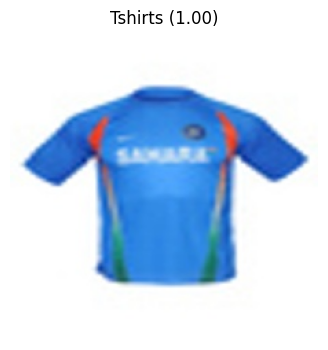


🖼 Image: 1530.jpg
   Predicted: Tshirts
   Probability: 0.8670


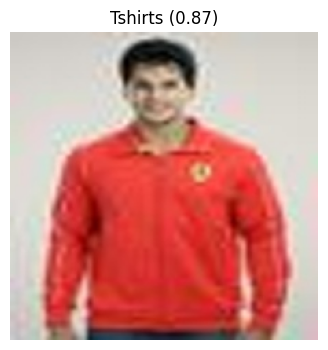


🖼 Image: 1535.jpg
   Predicted: Caps
   Probability: 0.7413


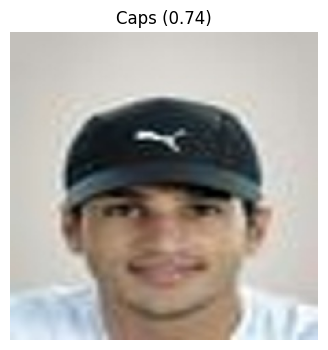


🖼 Image: 1543.jpg
   Predicted: Wristbands
   Probability: 0.2000


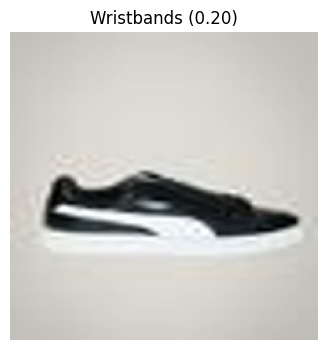


🖼 Image: 1546.jpg
   Predicted: Sports Shoes
   Probability: 0.7584


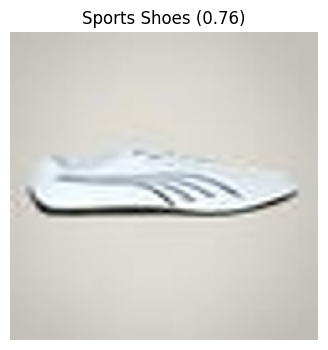

In [1]:
import os
import re
from pathlib import Path

import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
from product_tagger.modeling.vit import create_vit_model
from product_tagger.config import MODELS_DIR, PROCESSED_DATA_DIR
from product_tagger.config import PROCESSED_DATA_DIR

IMG_DIR = (PROCESSED_DATA_DIR / "images" / "test").as_posix()
print("IMG_DIR =", IMG_DIR)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


model_files = [f for f in os.listdir(MODELS_DIR) if f.endswith((".pt", ".pth"))]
if not model_files:
    raise FileNotFoundError(f"No .pt/.pth files found in {MODELS_DIR}")

model_filename = model_files[0]
MODEL_PATH = MODELS_DIR / model_filename
print("Using model file:", MODEL_PATH)


def numeric_sort_key(filename: str):
    m = re.search(r"\d+", filename)
    return int(m.group()) if m else float("inf")

def load_image(path: str, image_size=224, mean=None, std=None):
    if mean is None:
        mean = [0.485, 0.456, 0.406]
    if std is None:
        std = [0.229, 0.224, 0.225]

    transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Normalize(mean, std),
    ])

    img = Image.open(path).convert("RGB")
    return transform(img).unsqueeze(0), img


obj = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)

if not (isinstance(obj, dict) and "model_state_dict" in obj):
    raise RuntimeError("Unexpected checkpoint format. Expected dict with 'model_state_dict'.")

state = obj
model_state = state["model_state_dict"]
class_to_idx = state["class_to_idx"]
meta = state["meta"]

idx_to_class = {v: k for k, v in class_to_idx.items()}

mean = meta.get("mean", [0.485, 0.456, 0.406])
std  = meta.get("std",  [0.229, 0.224, 0.225])
image_size = meta.get("image_size", 224)
if isinstance(image_size, (tuple, list)):
    image_size = image_size[0]

model, _ = create_vit_model(num_classes=len(idx_to_class), pretrained=False)
model.load_state_dict(model_state)
model.to(DEVICE)
model.eval()

print("Model loaded with", len(idx_to_class), "classes.")


files = [f for f in os.listdir(IMG_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
files_sorted = sorted(files, key=numeric_sort_key)
first5 = files_sorted[:5]

print("Testing these images:")
for f in first5:
    print(" -", f)

softmax = torch.nn.Softmax(dim=1)


for fname in first5:
    path = os.path.join(IMG_DIR, fname)

    x, img_pil = load_image(path, image_size=image_size, mean=mean, std=std)
    x = x.to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = softmax(logits)
        prob, pred_idx = torch.max(probs, 1)

    predicted_class = idx_to_class[pred_idx.item()]

    print(f"\n🖼 Image: {fname}")
    print(f"   Predicted: {predicted_class}")
    print(f"   Probability: {prob.item():.4f}")

    plt.figure(figsize=(4, 4))
    plt.imshow(img_pil)
    plt.axis("off")
    plt.title(f"{predicted_class} ({prob.item():.2f})", fontsize=12)
    plt.show()
